In [42]:
# importing al the necessary libraries in this cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler,PowerTransformer
from sklearn.decomposition import PCA
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('processed data/clustered_data.csv')
df.shape

(2240, 22)

In [3]:
df_copy = df.copy()

In [4]:
df.head(3)

,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,...,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth,cluster
0,65,2,0,0,0,58138.0,1617.0,5053.0,58,635,...,120.5,81,88.0,8,10,4,3,0,7,0
1,68,2,0,1,2,46344.0,27.0,4503.0,38,11,...,2.0,1,6.0,1,1,2,2,0,5,2
2,57,2,1,0,0,71613.0,776.0,4702.0,26,426,...,111.0,21,42.0,8,2,10,1,0,4,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 2240 non-null   int64  
 1   Education           2240 non-null   int64  
 2   Marital Status      2240 non-null   int64  
 3   Parental Status     2240 non-null   int64  
 4   Children            2240 non-null   int64  
 5   Income              2240 non-null   float64
 6   Total_Spending      2240 non-null   float64
 7   Days_as_Customer    2240 non-null   float64
 8   Recency             2240 non-null   int64  
 9   Wines               2240 non-null   int64  
 10  Fruits              2240 non-null   int64  
 11  Meat                2240 non-null   int64  
 12  Fish                2240 non-null   float64
 13  Sweets              2240 non-null   int64  
 14  Gold                2240 non-null   float64
 15  Web                 2240 non-null   int64  
 16  Catalo

In [6]:
df['cluster'].value_counts()

cluster
2    948
1    704
0    588
Name: count, dtype: int64

In [7]:
x= df.drop(columns='cluster',axis=1)
y = df['cluster']

In [8]:
x.columns

Index(['Age', 'Education', 'Marital Status', 'Parental Status', 'Children',
       'Income', 'Total_Spending', 'Days_as_Customer', 'Recency', 'Wines',
       'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold', 'Web', 'Catalog', 'Store',
       'Discount Purchases', 'Total Promo', 'NumWebVisitsMonth'],
      dtype='object')

In [9]:
# we using bagging techniques 
models = {'Random forest': RandomForestClassifier(),
         'Adaboost classifies':AdaBoostClassifier(),
         'Gradient boosting':GradientBoostingClassifier(),
         'Support vector classifier':SVC(),
         'Logistic Regression':LogisticRegression(),
         'Decision tree classifier':DecisionTreeClassifier(),
         'KNeighbors Classifier':KNeighborsClassifier(),
         'XGB classsifer':XGBClassifier()}

In [10]:
print(list(models))

['Random forest', 'Adaboost classifies', 'Gradient boosting', 'Support vector classifier', 'Logistic Regression', 'Decision tree classifier', 'KNeighbors Classifier', 'XGB classsifer']


In [11]:
def evaluate(x,y,models):
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1)
    model_list = []
    eval_score_list = []
    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(x_train,y_train)
        y_pred = model.predict(x_test)
        evaluvation_score = accuracy_score(y_pred,y_test)
        model_list.append(model)
        eval_score_list.append(evaluvation_score)
        print(f'-----------score for {list(models.keys())[i]}---------------')
        print(f'the score is {evaluvation_score}')
    print()
    report = pd.DataFrame()
    report['model name'] = model_list
    report['eval score'] = eval_score_list
    return report

In [12]:
report = evaluate(x,y,models)

-----------score for Random forest---------------
the score is 0.9575892857142857
-----------score for Adaboost classifies---------------
the score is 0.9486607142857143
-----------score for Gradient boosting---------------
the score is 0.9642857142857143
-----------score for Support vector classifier---------------
the score is 0.765625
-----------score for Logistic Regression---------------
the score is 0.875
-----------score for Decision tree classifier---------------
the score is 0.9441964285714286
-----------score for KNeighbors Classifier---------------
the score is 0.8415178571428571
-----------score for XGB classsifer---------------
the score is 0.9575892857142857



In [13]:
report.sort_values('eval score')

,model name,eval score
3,SVC(),0.765625
6,KNeighborsClassifier(),0.841518
4,LogisticRegression(),0.875000
5,DecisionTreeClassifier(),0.944196
1,"(DecisionTreeClassifier(max_depth=1, random_st...",0.948661
0,"(DecisionTreeClassifier(max_features='sqrt', r...",0.957589
7,"XGBClassifier(base_score=None, booster=None, c...",0.957589
2,([DecisionTreeRegressor(criterion='friedman_ms...,0.964286


In [14]:
params = {'criterion':['gini', 'entropy', 'log_loss'],
         'splitter':['best', 'random'],
         'max_depth':[1,2,3,4,None],
         'min_samples_split':[1,2,3,4,5],
         'max_features':['sqrt','log2']}

In [15]:
shell_model = DecisionTreeClassifier()
grid_cv = GridSearchCV(shell_model,param_grid=params,cv=5,verbose=2)
grid_cv

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_split': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=1, test_size=0.3)

In [21]:
grid_cv.fit(x_train,y_train)

Fitting 5 folds for each of 300 candidates, totalling 1500 fits
[CV] END criterion=gini, max_depth=1, max_features=sqrt, min_samples_split=1, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, min_samples_split=1, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, min_samples_split=1, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, min_samples_split=1, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, min_samples_split=1, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, min_samples_split=1, splitter=random; total time=   0.0s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, min_samples_split=1, splitter=random; total time=   0.0s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, min_samples_split=1, splitter=random; total time=   0.0s
[CV] END criterion=gini, max_depth

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_split': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

In [23]:
grid_cv.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_split': 4,
 'splitter': 'best'}

In [38]:
final_model = grid_cv.best_estimator_
y_pred = final_model.predict(x_test)

In [39]:
accuracy_score(y_test,y_pred)

0.9285714285714286

In [40]:
grid_cv.best_score_

np.float64(0.9394232921592968)

In [41]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.91      0.90       173
           1       0.90      0.89      0.90       219
           2       0.97      0.97      0.97       280

    accuracy                           0.93       672
   macro avg       0.92      0.92      0.92       672
weighted avg       0.93      0.93      0.93       672



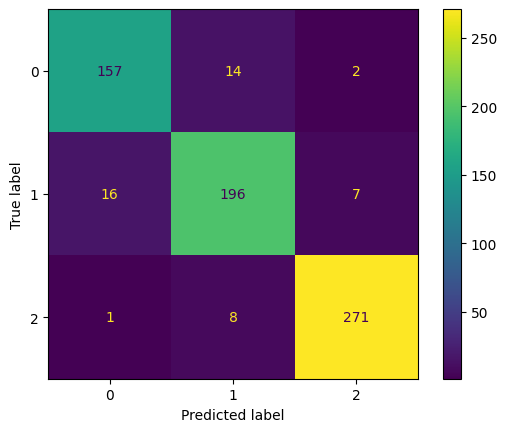

In [43]:
ConfusionMatrixDisplay.from_estimator(grid_cv,x_test,y_test)